In [1]:
import math
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# ---------------------------------------------------------
# 1. Data augmentation and shuffling
# ---------------------------------------------------------
def rotate_4x(x, y):
    """
    Augment data by creating 4 rotated versions of each image:
    0°, 90°, 180°, 270°. Returns the new (images, labels) with 4x samples.
    x: float32 NumPy array of shape (N, 28, 28, 1)
    y: int NumPy array of shape (N,)
    Returns:
      x_4x: float32 array of shape (4N, 28, 28, 1)
      y_4x: int array of shape (4N,)
    """
    all_images = []
    all_labels = []
    for k in range(4):
        rotated_batch = tf.image.rot90(x, k)  # Returns a tf.Tensor
        all_images.append(rotated_batch.numpy())  # Convert to NumPy
        all_labels.append(y)
    x_4x = np.concatenate(all_images, axis=0)
    y_4x = np.concatenate(all_labels, axis=0)
    return x_4x, y_4x

def shuffle_arrays_in_unison(a, b):
    """
    Shuffle two arrays (a, b) in unison along the first dimension, ensuring
    corresponding elements stay matched.
    """
    assert len(a) == len(b), "Arrays must have the same length."
    perm = np.random.permutation(len(a))
    return a[perm], b[perm]

In [3]:
# ---------------------------------------------------------
# 2. Data loading for Experiment 1 & 2
# ---------------------------------------------------------

def load_data_exp1():
    """
    Experiment 1:
      - The training and validation sets are non-rotated.
      - The test set is rotated.
    Detailed split:
      - From the original 60,000 training images, use the first 50,000 as train_no_rot 
        and the remaining 10,000 as val_no_rot.
      - For the test set: apply 4x rotations (resulting in 40,000 images) to the original test set (10,000 images),
        then randomly shuffle and select 10,000 images as test_rot.
    Returns:
      (x_train, y_train), (x_val, y_val), (x_test, y_test)
    where:
      x_train and x_val are non-rotated, and x_test is rotated.
    """
    (x_train_all, y_train_all), (x_test_orig, y_test_orig) = tf.keras.datasets.mnist.load_data()

    # Expand dimensions and normalize
    x_train_all = np.expand_dims(x_train_all, axis=-1).astype("float32") / 255.0
    x_test_orig = np.expand_dims(x_test_orig, axis=-1).astype("float32") / 255.0
    
    # Shuffle the training set and then split: first 50,000 for training, last 10,000 for validation
    x_train_all, y_train_all = shuffle_arrays_in_unison(x_train_all, y_train_all)
    x_train_no_rot = x_train_all[:50000]
    y_train_no_rot = y_train_all[:50000]
    x_val_no_rot   = x_train_all[50000:]
    y_val_no_rot   = y_train_all[50000:]
    
    # For the test set, apply 4x rotations and then randomly select 10,000 samples
    x_test_4x, y_test_4x = rotate_4x(x_test_orig, y_test_orig)  # (40,000, 28, 28, 1)
    x_test_4x, y_test_4x = shuffle_arrays_in_unison(x_test_4x, y_test_4x)
    x_test_rot = x_test_4x[:10000]
    y_test_rot = y_test_4x[:10000]
    
    return (x_train_no_rot, y_train_no_rot), (x_val_no_rot, y_val_no_rot), (x_test_rot, y_test_rot)

def load_data_exp2():
    """
    Experiment 2:
      - The training, validation, and test sets are all rotated.
    Detailed split:
      - For the original 60,000 training images, apply 4x rotations (resulting in 240,000 images),
        shuffle, and then select 60,000 samples.
        Then, split: the first 50,000 as train_rot and the remaining 10,000 as val_rot.
      - For the test set: apply 4x rotations (resulting in 40,000 images) to the original test set (10,000 images),
        shuffle, and then select 10,000 samples as test_rot.
    Returns:
      (x_train, y_train), (x_val, y_val), (x_test, y_test)
    where:
      x_train, x_val, and x_test are all rotated.
    """
    (x_train_all, y_train_all), (x_test_orig, y_test_orig) = tf.keras.datasets.mnist.load_data()

    # Expand dimensions and normalize
    x_train_all = np.expand_dims(x_train_all, axis=-1).astype("float32") / 255.0
    x_test_orig = np.expand_dims(x_test_orig, axis=-1).astype("float32") / 255.0
    
    # Apply 4x rotations to the training set, resulting in (240,000, 28, 28, 1)
    x_train_4x, y_train_4x = rotate_4x(x_train_all, y_train_all)
    x_train_4x, y_train_4x = shuffle_arrays_in_unison(x_train_4x, y_train_4x)
    # Select 60,000 samples from the 240,000
    x_train_4x_60k = x_train_4x[:60000]
    y_train_4x_60k = y_train_4x[:60000]
    # Split the 60,000: first 50,000 for training, remaining 10,000 for validation
    x_train_rot = x_train_4x_60k[:50000]
    y_train_rot = y_train_4x_60k[:50000]
    x_val_rot   = x_train_4x_60k[50000:]
    y_val_rot   = y_train_4x_60k[50000:]
    
    # For the test set, apply 4x rotations (resulting in 40,000 images),
    # shuffle, and select 10,000 samples
    x_test_4x, y_test_4x = rotate_4x(x_test_orig, y_test_orig)  # (40,000, 28, 28, 1)
    x_test_4x, y_test_4x = shuffle_arrays_in_unison(x_test_4x, y_test_4x)
    x_test_rot = x_test_4x[:10000]
    y_test_rot = y_test_4x[:10000]
    
    return (x_train_rot, y_train_rot), (x_val_rot, y_val_rot), (x_test_rot, y_test_rot)


<!-- # # ---------------------------------------------------------
# # 3. Custom rotation-equivariant layer
# # ---------------------------------------------------------

# class RotationEquivariantConv(layers.Layer):
#     """
#     A custom layer that applies the same Conv2D operation to the input
#     under 4 rotations (0°, 90°, 180°, 270°), then averages the results.
#     """
#     def __init__(self, filters, kernel_size, activation=None, **kwargs):
#         super().__init__(**kwargs)
#         self.filters = filters
#         self.kernel_size = kernel_size
#         self.activation = activation
        
#         # Shared convolution across all rotations
#         self.shared_conv = layers.Conv2D(
#             filters=self.filters,
#             kernel_size=self.kernel_size,
#             padding='same',
#             activation=self.activation)
    
#     def call(self, inputs, training=None):
#         # Rotate the input 4 ways: 0°, 90°, 180°, 270°
#         rotations = []
#         for i in range(4):
#             rotated = tf.image.rot90(inputs, k=i)
#             rotations.append(rotated)
        
#         # Apply the shared conv to each rotated version
#         conv_results = []
#         for rot in rotations:
#             conv_out = self.shared_conv(rot)
#             conv_results.append(conv_out)
        
#         # Take the average of the 4 results
#         output = tf.reduce_mean(conv_results, axis=0)
#         return output -->

In [4]:
class RotationEquivariantConv(layers.Layer):
    """
    A 'true' rotation-equivariant layer for the 4 discrete rotations 0°,90°,180°,270°.
    - Same interface as the previous version (same class name, constructor, call signature).
    - Does NOT rotate the convolution outputs back, thus preserving equivariance
      in the extended (space + orientation) representation.
    """

    def __init__(self, filters, kernel_size, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters            # #channels per orientation
        self.kernel_size = kernel_size
        self.activation = activation

        # Shared convolution for all 4 orientations (same weights)
        # Activation is applied internally by Conv2D if activation!=None
        self.shared_conv = layers.Conv2D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            padding="same",
            activation=self.activation)

    def call(self, inputs, training=None):
        oriented_feats = []
        # Process input in all 4 orientations (0°,90°,180°,270°)
        for k in range(4):
            x_k = tf.image.rot90(inputs, k=k)  # rotate input
            y_k = self.shared_conv(x_k)        # same kernel over this rotated input
            # No "rotate back" here => preserving orientation channel
            oriented_feats.append(y_k)

        # Concatenate the 4 orientations along channel axis -> shape: (B,H,W,4*filters)
        output = tf.concat(oriented_feats, axis=-1)
        return output


In [5]:
# ---------------------------------------------------------
# 4. Models for comparison
# ---------------------------------------------------------

def build_mlp_model():
    """
    Baseline MLP model on (28,28,1) input.
    """
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Flatten()(inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model


def build_rotation_model():
    """
    Model that turns RotationEquivariantConv outputs into rotation-invariant
    representations via orientation pooling (max over the 4 directions).
    Interface and names stay unchanged.
    """
    inputs = layers.Input(shape=(28, 28, 1))
    x = RotationEquivariantConv(filters=16, kernel_size=3, activation='relu')(inputs)  # (B, 28, 28, 64)
    
    # Reshape to (B, H, W, 4, F) and pool over the orientation dimension (axis=3)
    x = layers.Reshape((28, 28, 4, 16))(x)
    x = layers.Lambda(lambda t: tf.reduce_mean(t, axis=3))(x)                           # (B, 28, 28, 16)
    
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model


<!-- def build_rotation_model():
    """
    Model that uses RotationEquivariantConv (16 filters) for 0°, 90°, 180°, 270°.
    """
    inputs = layers.Input(shape=(28, 28, 1))
    x = RotationEquivariantConv(filters=16, kernel_size=3, activation='relu')(inputs)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model -->


<!-- def plot_history(history, title):
    """
    Plot the loss and accuracy curves from a Keras history object.
    Shows them on screen but does NOT save any image file.
    """
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot loss
    axs[0].plot(history.history['loss'], label='train_loss')
    axs[0].plot(history.history['val_loss'], label='val_loss')
    axs[0].set_title(f'{title} - Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()

    # Plot accuracy
    axs[1].plot(history.history['accuracy'], label='train_accuracy')
    axs[1].plot(history.history['val_accuracy'], label='val_accuracy')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    
    plt.tight_layout()
    plt.show() -->

In [6]:
# ---------------------------------------------------------
# 5. Plotting Functions
# ---------------------------------------------------------
def plot_history(history, title):
    """
    Plot the loss and accuracy curves from a Keras history object.
    Shows them on screen but does NOT save any image file.
    """
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot loss with markers
    axs[0].plot(history.history['loss'], marker='o', linestyle='-', label='train_loss')
    axs[0].plot(history.history['val_loss'], marker='o', linestyle='-', label='val_loss')
    axs[0].set_title(f'{title} - Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()

    # Plot accuracy with markers
    axs[1].plot(history.history['accuracy'], marker='o', linestyle='-', label='train_accuracy')
    axs[1].plot(history.history['val_accuracy'], marker='o', linestyle='-', label='val_accuracy')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    
    plt.tight_layout()
    plt.show()


def inspect_images_grid(x_data, y_data, num_images=5):
    """
    Display a specified number of images from x_data along with their labels from y_data
    in a grid layout with 5 images per row.

    x_data: np.array of shape (N, 28, 28, 1) or (N, 28, 28)
    y_data: np.array of shape (N,)
    num_images: int, number of images to display in total

    Example:
        inspect_images_grid(x_train_4x, y_train_4x, num_images=10)
        # This will show 2 rows, 5 images in each row.
    """
    cols = 5
    rows = math.ceil(num_images / cols)

    plt.figure(figsize=(15, 3 * rows))  # Adjust figure size as needed
    for i in range(num_images):
        plt.subplot(rows, cols, i + 1)
        # If x_data has shape (N,28,28,1), we can reshape to (28,28) for imshow
        image_2d = x_data[i].reshape(28, 28)
        plt.imshow(image_2d, cmap='gray')
        plt.title(f"Label: {y_data[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [7]:
# ---------------------------------------------------------
# 6. Utility: Save model weights to "models/" folder
# ---------------------------------------------------------
def save_model_weights(model, filename):
    """
    Save model weights into the "models/" directory (create if not exists).
    """
    os.makedirs("models", exist_ok=True)  # ensure directory exists
    model.save_weights(os.path.join("models", filename))

Non-rotated images:


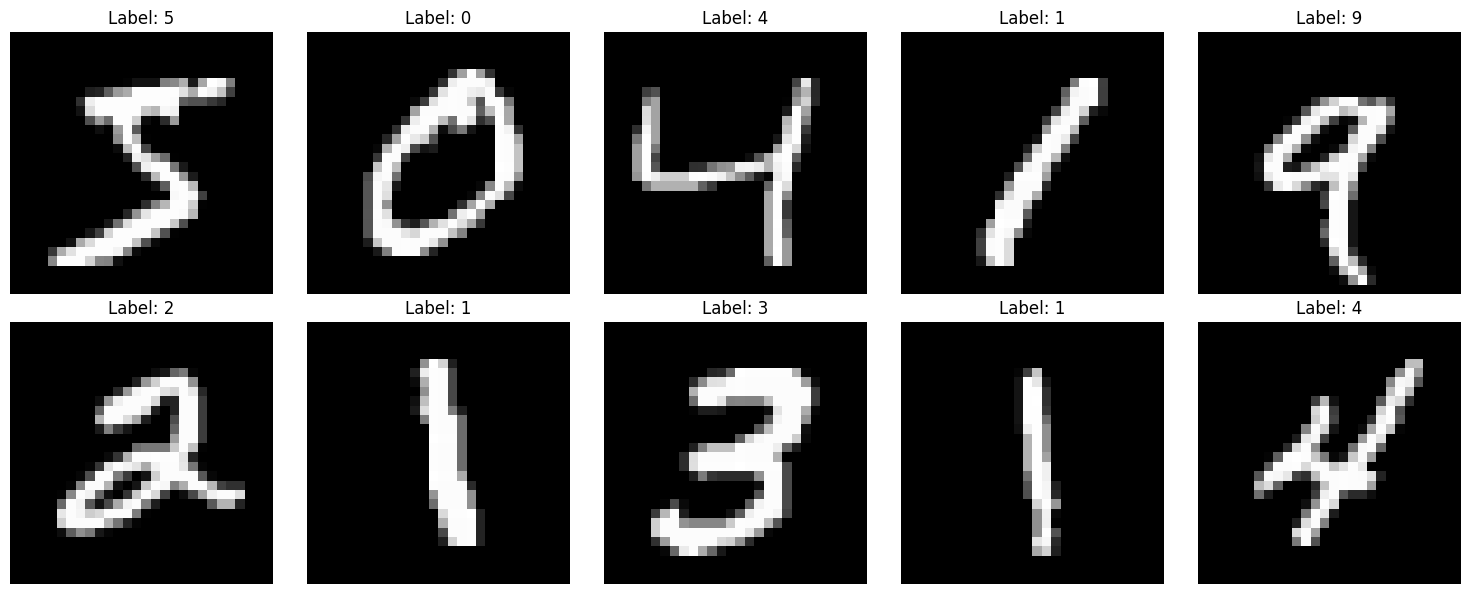

Rotated images (one of the 4 rotations for each original image):


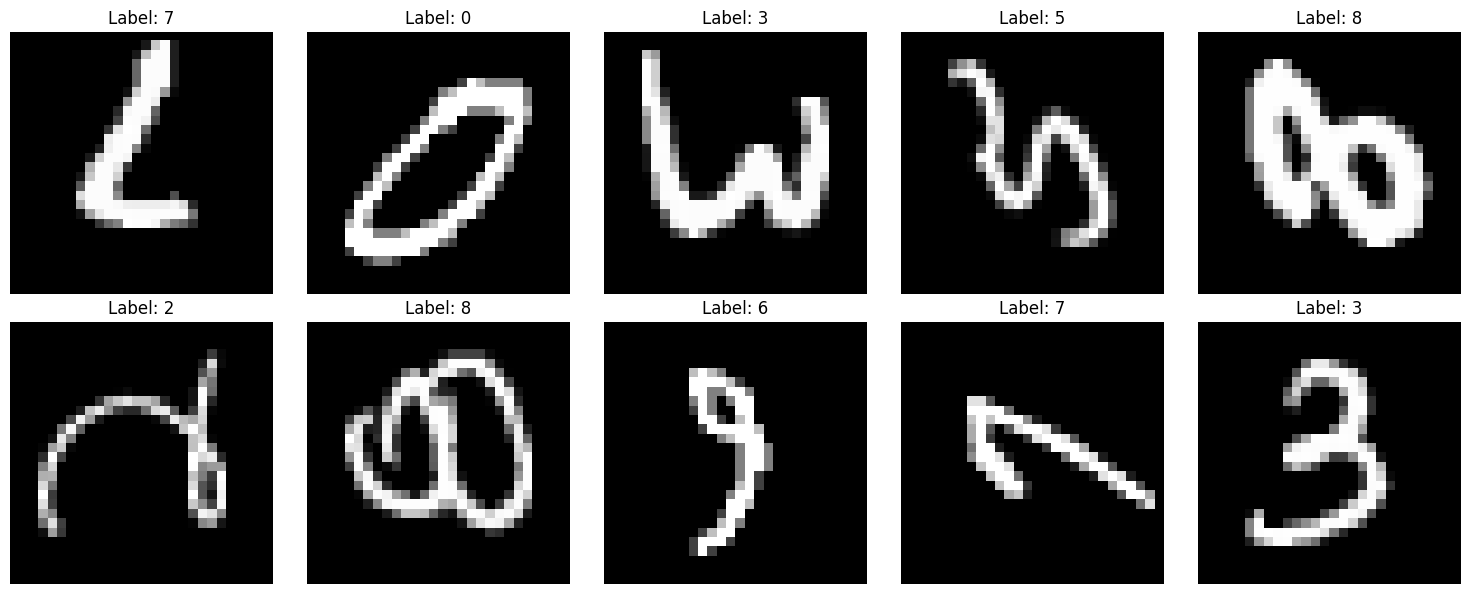

In [8]:
# Load MNIST dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train, axis=-1).astype("float32") / 255.0

# Display non-rotated images
print("Non-rotated images:")
inspect_images_grid(x_train, y_train, num_images=10)

# Create rotated version using rotate_4x function.
# Note: rotate_4x produces 4x images (for each image: 0°, 90°, 180°, 270°).
x_train_rot, y_train_rot = rotate_4x(x_train, y_train)

# Display a grid from the rotated images.
# Since rotate_4x returns 4N images, here we randomly select 10 images to display.
print("Rotated images (one of the 4 rotations for each original image):")
# Randomly sample 10 images from the rotated set:
indices = np.random.choice(x_train_rot.shape[0], size=10, replace=False)
inspect_images_grid(x_train_rot[indices], y_train_rot[indices], num_images=10)

=== Experiment 1: Train(no-rot), Val(no-rot), Test(rot) ===

[Experiment 1 - MLP] Training...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8180 - loss: 0.6534 - val_accuracy: 0.9461 - val_loss: 0.1840
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9527 - loss: 0.1629 - val_accuracy: 0.9575 - val_loss: 0.1483
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9666 - loss: 0.1141 - val_accuracy: 0.9642 - val_loss: 0.1201
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9748 - loss: 0.0807 - val_accuracy: 0.9670 - val_loss: 0.1122
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9824 - loss: 0.0596 - val_accuracy: 0.9727 - val_loss: 0.0960
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9843 - loss: 0.0507 - val_accuracy: 0.9709 - val_loss: 0.0981
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9883 - loss: 0.0386 - val_accuracy: 0.9738 - val_loss: 0.0930
Epoch 8/10

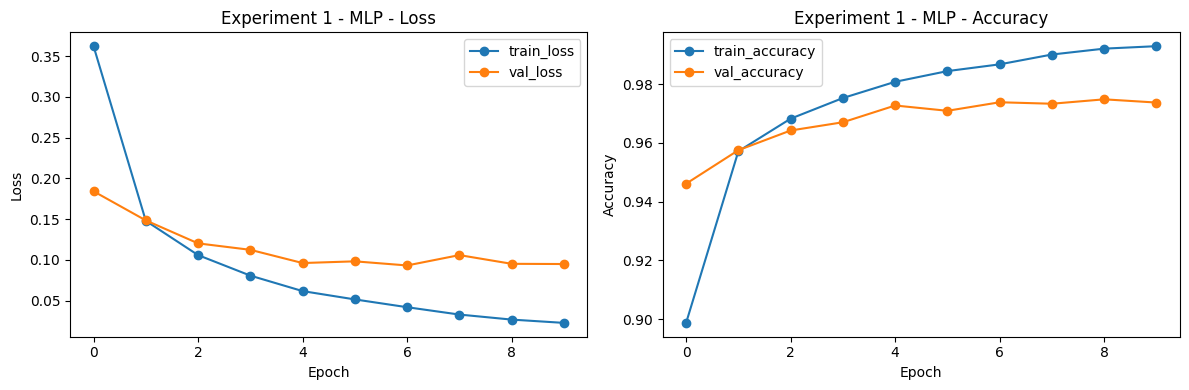

[Experiment 1 - MLP] Test(rot) -> Loss: 6.5938, Accuracy: 0.3897


[Experiment 1 - Rotation Model] Training...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6686 - loss: 1.0306 - val_accuracy: 0.8668 - val_loss: 0.4356
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8879 - loss: 0.3710 - val_accuracy: 0.8960 - val_loss: 0.3391
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9106 - loss: 0.2871 - val_accuracy: 0.9130 - val_loss: 0.2777
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9247 - loss: 0.2424 - val_accuracy: 0.9230 - val_loss: 0.2507
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9354 - loss: 0.2077 - val_accuracy: 0.9235 - val_loss: 0.2410
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9402 - loss: 0.1889 - val_accuracy: 0.9243 - val_loss: 0.2371
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9488 - loss: 0.1651 - val_accuracy: 0.9348 - val

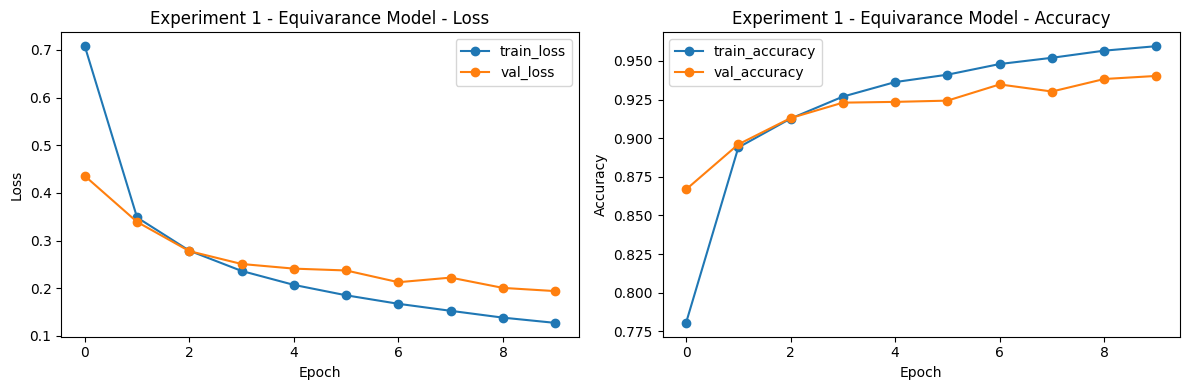

[Experiment 1 - Rotation Model] Test(rot) -> Loss: 0.1911, Accuracy: 0.9425


In [9]:
# ---------------------------------------------------------
# 7. Experiment 1: Train(no-rot, val(no-rot)), Test(rot)
# ---------------------------------------------------------

def experiment1():
    print("=== Experiment 1: Train(no-rot), Val(no-rot), Test(rot) ===")
    (x_train, y_train), (x_val, y_val), (x_test, y_test) = load_data_exp1()
    
    mlp = build_mlp_model()
    mlp.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
    
    print("\n[Experiment 1 - MLP] Training...")
    history_mlp = mlp.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=128,
        verbose=1)
    
    plot_history(history_mlp, title="Experiment 1 - MLP")
    
    save_model_weights(mlp, "mlp_exp1.weights.h5")
    
    loss_mlp, acc_mlp = mlp.evaluate(x_test, y_test, verbose=0) # Evaluate on test(rot)
    print(f"[Experiment 1 - MLP] Test(rot) -> Loss: {loss_mlp:.4f}, Accuracy: {acc_mlp:.4f}")
    
    rot_model = build_rotation_model()
    rot_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    
    print("\n[Experiment 1 - Rotation Model] Training...")
    history_rot = rot_model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=128,
        verbose=1)
    plot_history(history_rot, title="Experiment 1 - Equivarance Model")
    
    save_model_weights(rot_model, "rot_exp1.weights.h5")
    
    loss_rot, acc_rot = rot_model.evaluate(x_test, y_test, verbose=0)
    print(f"[Experiment 1 - Rotation Model] Test(rot) -> Loss: {loss_rot:.4f}, Accuracy: {acc_rot:.4f}")
    
    return (loss_mlp, acc_mlp), (loss_rot, acc_rot)

results_mlp_exp1, results_rot_exp1 = experiment1()


=== Experiment 2: Train(rot), Val(rot), Test(rot) ===

[Experiment 2 - MLP] Training...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5867 - loss: 1.2473 - val_accuracy: 0.8486 - val_loss: 0.5176
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8735 - loss: 0.4330 - val_accuracy: 0.8966 - val_loss: 0.3559
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9145 - loss: 0.2879 - val_accuracy: 0.9103 - val_loss: 0.3033
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9361 - loss: 0.2165 - val_accuracy: 0.9165 - val_loss: 0.2816
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9474 - loss: 0.1783 - val_accuracy: 0.9198 - val_loss: 0.2687
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9546 - loss: 0.1470 - val_accuracy: 0.9233 - val_loss: 0.2627
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9647 - loss: 0.1177 - val_accuracy: 0.9278 - val_loss: 0.2500
Epoch 8/10
391/

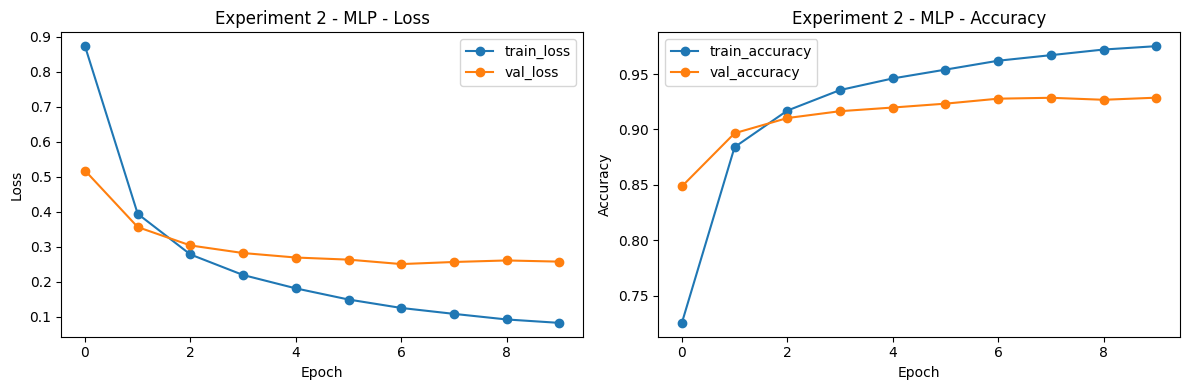

[Experiment 2 - MLP] Test(rot) -> Loss: 0.2481, Accuracy: 0.9317

[Experiment 2 - Rotation Model] Training...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6718 - loss: 1.0330 - val_accuracy: 0.8773 - val_loss: 0.4028
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8820 - loss: 0.3855 - val_accuracy: 0.8974 - val_loss: 0.3337
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9067 - loss: 0.3019 - val_accuracy: 0.9147 - val_loss: 0.2750
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9231 - loss: 0.2532 - val_accuracy: 0.9079 - val_loss: 0.2839
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9304 - loss: 0.2257 - val_accuracy: 0.9300 - val_loss: 0.2327
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9421 - loss: 0.1917 - val_accuracy: 0.9306 - val_loss: 0.2300
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9497 - loss: 0.1666 - val_accuracy: 0.9364 - val_

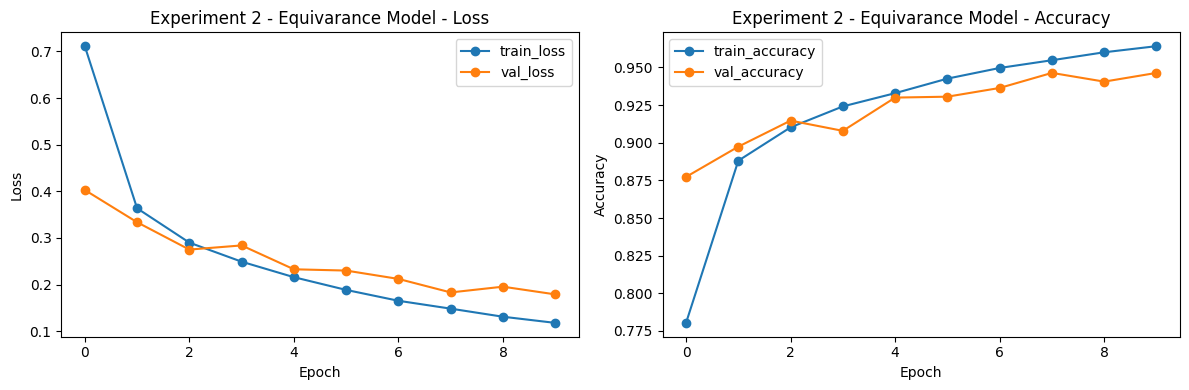

[Experiment 2 - Rotation Model] Test(rot) -> Loss: 0.2192, Accuracy: 0.9289


In [10]:
# ---------------------------------------------------------
# 8. Experiment 2: Train(rot), Val(rot), Test(rot)
# ---------------------------------------------------------

def experiment2():
    print("\n=== Experiment 2: Train(rot), Val(rot), Test(rot) ===")
    (x_train, y_train), (x_val, y_val), (x_test, y_test) = load_data_exp2()
    
    mlp = build_mlp_model()
    mlp.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
    
    print("\n[Experiment 2 - MLP] Training...")
    history_mlp = mlp.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=128,
        verbose=1)
    
    plot_history(history_mlp, title="Experiment 2 - MLP")
    
    save_model_weights(mlp, "mlp_exp2.weights.h5")
    
    loss_mlp, acc_mlp = mlp.evaluate(x_test, y_test, verbose=0) # Evaluate on test(rot)
    print(f"[Experiment 2 - MLP] Test(rot) -> Loss: {loss_mlp:.4f}, Accuracy: {acc_mlp:.4f}")
    
    rot_model = build_rotation_model() # Build Rotation Model
    rot_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    
    print("\n[Experiment 2 - Rotation Model] Training...")
    history_rot = rot_model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=128,
        verbose=1)
    
    plot_history(history_rot, title="Experiment 2 - Equivarance Model")
    
    save_model_weights(rot_model, "rot_exp2.weights.h5")
    
    loss_rot, acc_rot = rot_model.evaluate(x_test, y_test, verbose=0)
    print(f"[Experiment 2 - Rotation Model] Test(rot) -> Loss: {loss_rot:.4f}, Accuracy: {acc_rot:.4f}")
    
    return (loss_mlp, acc_mlp), (loss_rot, acc_rot)

results_mlp_exp2, results_rot_exp2 = experiment2()

In [ ]:
# ---------------------------------------------------------
# 9. Final Comparsion
# ---------------------------------------------------------
print("\n========== FINAL COMPARISON ==========")

# ---------- Experiment 1 ----------
(x_train1, y_train1), (x_val1, y_val1), (x_test1, y_test1) = load_data_exp1()

mlp_exp1 = build_mlp_model()
mlp_exp1.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
mlp_exp1.load_weights("models/mlp_exp1.weights.h5")

rot_exp1 = build_rotation_model()
rot_exp1.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
rot_exp1.load_weights("models/rot_exp1.weights.h5")

tr_loss_mlp1, tr_acc_mlp1 = mlp_exp1.evaluate(x_train1, y_train1, verbose=0)
va_loss_mlp1, va_acc_mlp1 = mlp_exp1.evaluate(x_val1,   y_val1,   verbose=0)
te_loss_mlp1, te_acc_mlp1 = results_mlp_exp1  

tr_loss_rot1, tr_acc_rot1 = rot_exp1.evaluate(x_train1, y_train1, verbose=0)
va_loss_rot1, va_acc_rot1 = rot_exp1.evaluate(x_val1,   y_val1,   verbose=0)
te_loss_rot1, te_acc_rot1 = results_rot_exp1

print("Experiment 1 (Train: no-rot, Val: no-rot, Test: rot)")
print(f"  MLP                -> "
      f"Train Loss={tr_loss_mlp1:.4f}, Acc={tr_acc_mlp1:.4f} | "
      f"Val Loss={va_loss_mlp1:.4f}, Acc={va_acc_mlp1:.4f} | "
      f"Test Loss={te_loss_mlp1:.4f}, Acc={te_acc_mlp1:.4f}")
print(f"  Equivariance Model -> "
      f"Train Loss={tr_loss_rot1:.4f}, Acc={tr_acc_rot1:.4f} | "
      f"Val Loss={va_loss_rot1:.4f}, Acc={va_acc_rot1:.4f} | "
      f"Test Loss={te_loss_rot1:.4f}, Acc={te_acc_rot1:.4f}")

# ---------- Experiment 2 ----------
(x_train2, y_train2), (x_val2, y_val2), (x_test2, y_test2) = load_data_exp2()

mlp_exp2 = build_mlp_model()
mlp_exp2.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
mlp_exp2.load_weights("models/mlp_exp2.weights.h5")

rot_exp2 = build_rotation_model()
rot_exp2.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
rot_exp2.load_weights("models/rot_exp2.weights.h5")

tr_loss_mlp2, tr_acc_mlp2 = mlp_exp2.evaluate(x_train2, y_train2, verbose=0)
va_loss_mlp2, va_acc_mlp2 = mlp_exp2.evaluate(x_val2,   y_val2,   verbose=0)
te_loss_mlp2, te_acc_mlp2 = results_mlp_exp2  

tr_loss_rot2, tr_acc_rot2 = rot_exp2.evaluate(x_train2, y_train2, verbose=0)
va_loss_rot2, va_acc_rot2 = rot_exp2.evaluate(x_val2,   y_val2,   verbose=0)
te_loss_rot2, te_acc_rot2 = results_rot_exp2

print("\nExperiment 2 (Train: rot, Val: rot, Test: rot)")
print(f"  MLP                -> "
      f"Train Loss={tr_loss_mlp2:.4f}, Acc={tr_acc_mlp2:.4f} | "
      f"Val Loss={va_loss_mlp2:.4f}, Acc={va_acc_mlp2:.4f} | "
      f"Test Loss={te_loss_mlp2:.4f}, Acc={te_acc_mlp2:.4f}")
print(f"  Equivariance Model -> "
      f"Train Loss={tr_loss_rot2:.4f}, Acc={tr_acc_rot2:.4f} | "
      f"Val Loss={va_loss_rot2:.4f}, Acc={va_acc_rot2:.4f} | "
      f"Test Loss={te_loss_rot2:.4f}, Acc={te_acc_rot2:.4f}")

print("=========================================")



========== FINAL COMPARISON ==========


c:\Users\woyao\miniconda3\envs\a3_cw\lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Experiment 1 (Train: no-rot, Val: no-rot, Test: rot)
  MLP                -> Train Loss=0.0289, Acc=0.9922 | Val Loss=0.0317, Acc=0.9920 | Test Loss=6.5938, Acc=0.3897
  Equivariance Model -> Train Loss=0.1188, Acc=0.9645 | Val Loss=0.1241, Acc=0.9656 | Test Loss=0.1911, Acc=0.9425

Experiment 2 (Train: rot, Val: rot, Test: rot)
  MLP                -> Train Loss=0.2152, Acc=0.9415 | Val Loss=0.2120, Acc=0.9409 | Test Loss=0.2481, Acc=0.9317
  Equivariance Model -> Train Loss=0.1569, Acc=0.9519 | Val Loss=0.1625, Acc=0.9514 | Test Loss=0.2192, Acc=0.9289
